In [2]:
import torch
import torchvision ## Contains some utilities for working with the image data
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
#%matplotlib inline
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F


In [3]:
dataset = MNIST(root='data/', download=True)

100.0%
100.0%
100.0%
100.0%


In [4]:
print("Number of samples in the dataset:", len(dataset))

Number of samples in the dataset: 60000


Label: 0


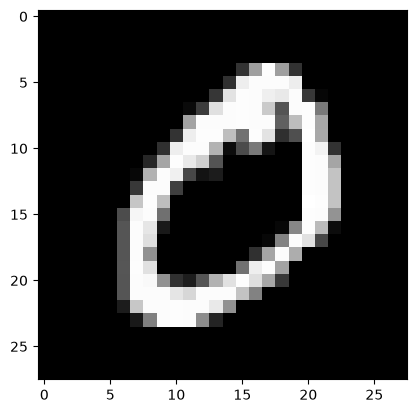

In [8]:
image, label = dataset[1]
plt.imshow(image, cmap='gray')
print("Label:", label)

In [9]:
mnist_dataset = MNIST(root='data/', train=True, download=True, transform=transforms.ToTensor())

In [12]:
image_tensor , label = mnist_dataset[7]
print(image_tensor.shape, label)

torch.Size([1, 28, 28]) 3


In [14]:
print(image_tensor[:, 10:15, 10:15])
print(torch.max(image_tensor), torch.min(image_tensor), label)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.3569],
         [0.4902, 0.7569, 0.7569, 0.7569, 0.9922],
         [0.9882, 0.9882, 0.9882, 0.9882, 0.9922]]])
tensor(1.) tensor(0.) 3


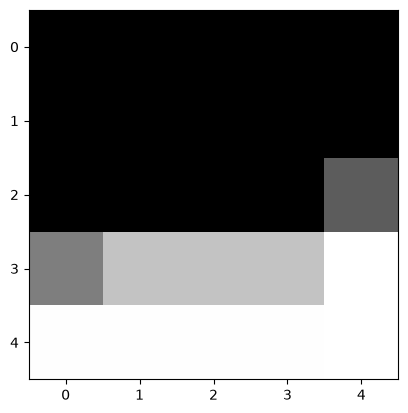

In [15]:
## Plot the image of the tensor
plt.imshow(image_tensor[0,10:15,10:15],cmap = 'gray')

In [16]:
train_data, validation_data = random_split(mnist_dataset, [50000, 10000])
## Print the length of train and validation datasets
print("length of Train Datasets: ", len(train_data))
print("length of Validation Datasets: ", len(validation_data))

length of Train Datasets:  50000
length of Validation Datasets:  10000


In [17]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(validation_data, batch_size, shuffle = False)

In [18]:
import torch.nn as nn

input_size = 28 * 28
num_classes = 10

## Logistic regression model
model = nn.Linear(input_size, num_classes)
print(model.weight.shape)
print(model.weight)
print(model.bias.shape)
print(model.bias)

torch.Size([10, 784])
Parameter containing:
tensor([[ 0.0260, -0.0093, -0.0242,  ..., -0.0136,  0.0268, -0.0194],
        [-0.0203, -0.0167,  0.0313,  ..., -0.0009,  0.0324, -0.0182],
        [-0.0194, -0.0214, -0.0135,  ...,  0.0077, -0.0176, -0.0168],
        ...,
        [ 0.0147,  0.0204, -0.0208,  ..., -0.0048,  0.0300, -0.0190],
        [ 0.0232, -0.0349,  0.0339,  ..., -0.0220, -0.0334,  0.0250],
        [-0.0283,  0.0029, -0.0131,  ...,  0.0008, -0.0114,  0.0310]],
       requires_grad=True)
torch.Size([10])
Parameter containing:
tensor([-0.0129, -0.0327,  0.0327,  0.0263,  0.0294, -0.0346, -0.0272, -0.0140,
        -0.0318,  0.0101], requires_grad=True)


In [20]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        print(xb)
        out = self.linear(xb)
        print(out)
        return(out)

model = MnistModel()
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[ 0.0036, -0.0033,  0.0102,  ...,  0.0349, -0.0312, -0.0132],
         [ 0.0128,  0.0142, -0.0294,  ...,  0.0003,  0.0304,  0.0212],
         [ 0.0031,  0.0313, -0.0345,  ...,  0.0299,  0.0158,  0.0160],
         ...,
         [-0.0004, -0.0292,  0.0155,  ...,  0.0199,  0.0276,  0.0032],
         [ 0.0197, -0.0124, -0.0020,  ..., -0.0145,  0.0067, -0.0064],
         [ 0.0082,  0.0231,  0.0057,  ...,  0.0139,  0.0164,  0.0122]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0218, -0.0101, -0.0214,  0.0356,  0.0173,  0.0193, -0.0353,  0.0248,
         -0.0187,  0.0288], requires_grad=True)]